In [1]:
import os

files = os.listdir("train")

sat_ids = {
    f.replace("_sat.jpg", "")
    for f in files
    if f.endswith("_sat.jpg")
}

mask_ids = {
    f.replace("_mask.png", "")
    for f in files
    if f.endswith("_mask.png")
}

common_ids = sorted(
    list(sat_ids & mask_ids)
)

print("Pairs:", len(common_ids))
print(common_ids[:5])

Pairs: 6226
['100034', '100081', '100129', '100703', '100712']


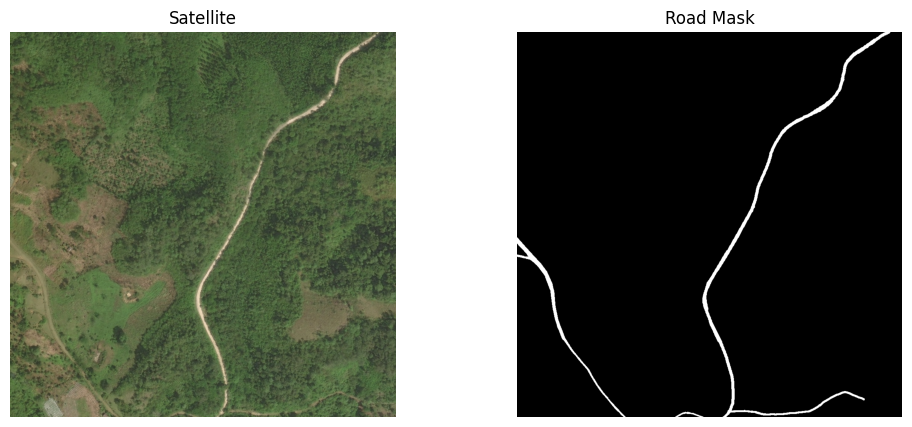

In [2]:
import cv2
import matplotlib.pyplot as plt

image_id = common_ids[0]

img = cv2.imread(
    f"train/{image_id}_sat.jpg"
)

mask = cv2.imread(
    f"train/{image_id}_mask.png",
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(
    cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Satellite")

plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    mask,
    cmap="gray"
)
plt.title("Road Mask")
plt.axis("off")

plt.show()

In [3]:
import segmentation_models_pytorch as smp
import torch

device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

model.load_state_dict(
    torch.load(
        "deeplabv3plus_road.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Model Loaded Successfully")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model Loaded Successfully


CODE FOR THE MODEL TRAINING

In [4]:
test_id = common_ids[0]

img = cv2.imread(
    f"train/{test_id}_sat.jpg"
)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img_resized = cv2.resize(
    img_rgb,
    (512,512)
)

x = img_resized.astype("float32") / 255.0

x = torch.tensor(
    x.transpose(2,0,1)
).unsqueeze(0)

x = x.to(device)

with torch.no_grad():
    pred = model(x)

pred = torch.sigmoid(pred)

pred = pred.squeeze().cpu().numpy()

print("Min:", pred.min())
print("Max:", pred.max())
print("Mean:", pred.mean())

Min: 1.1185167e-07
Max: 0.99999976
Mean: 0.015950195


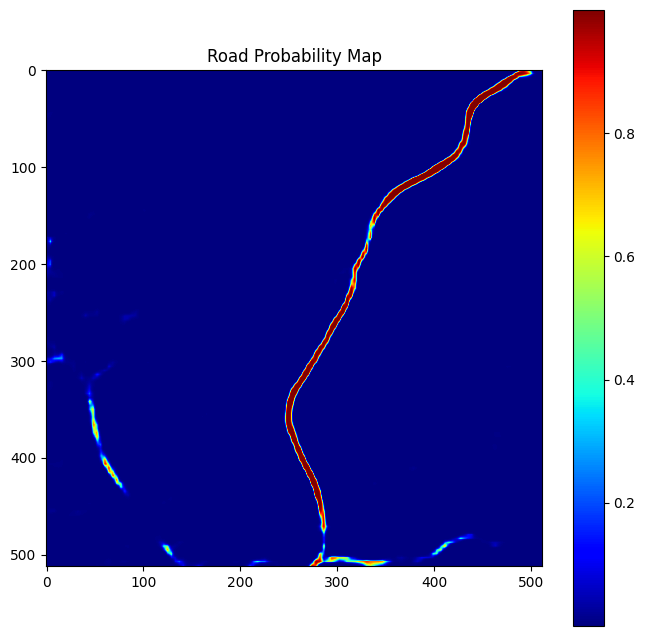

In [5]:
plt.figure(figsize=(8,8))

plt.imshow(
    pred,
    cmap="jet"
)

plt.colorbar()

plt.title(
    "Road Probability Map"
)

plt.show()

Road %: 1.48162841796875


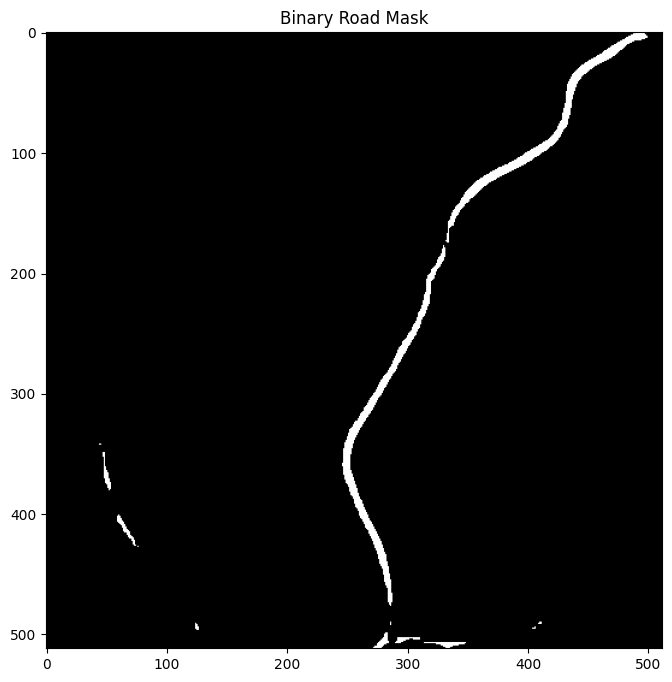

In [6]:
import numpy as np
pred_binary = (
    pred > 0.5
).astype("uint8")

road_pixels = np.sum(
    pred_binary
)

total_pixels = (
    pred_binary.shape[0]
    *
    pred_binary.shape[1]
)

print(
    "Road %:",
    100 * road_pixels / total_pixels
)

plt.figure(figsize=(8,8))

plt.imshow(
    pred_binary,
    cmap="gray"
)

plt.title(
    "Binary Road Mask"
)

plt.show()

In [9]:
mask = cv2.imread(
    f"train/{test_id}_mask.png",
    0
)

mask = cv2.resize(mask, (512,512))
mask = (mask > 127).astype(np.uint8)

pred_binary = (pred > 0.5).astype(np.uint8)

intersection = (pred_binary & mask).sum()
union = (pred_binary | mask).sum()

iou = intersection / union

dice = (2 * intersection) / (
    pred_binary.sum() + mask.sum()
)

print("IoU :", iou)
print("Dice:", dice)

IoU : 0.49085891686788546
Dice: 0.6584914391485424


Junction Count: 3848


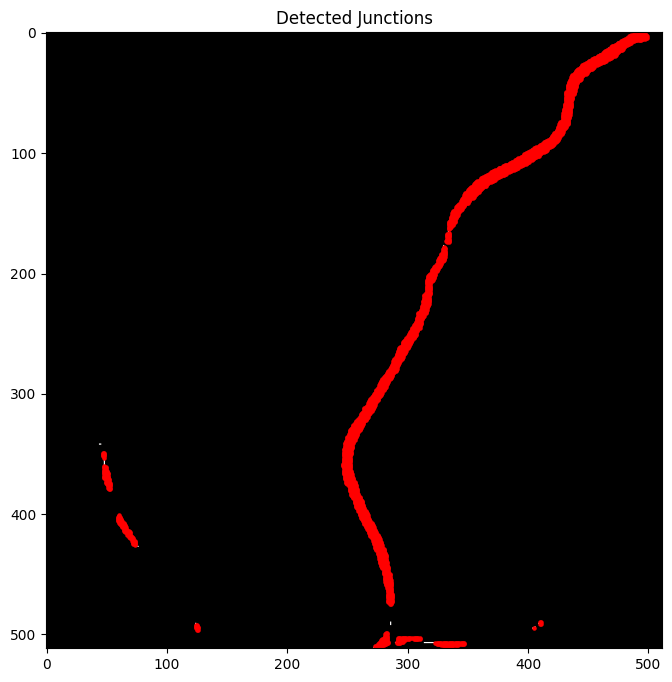

In [8]:
from scipy.ndimage import convolve

kernel = np.array([
    [1,1,1],
    [1,10,1],
    [1,1,1]
])

neighbors = convolve(
    pred_binary,
    np.ones((3,3)),
    mode="constant"
)

junctions = (
    (pred_binary == 1)
    &
    (neighbors >= 4)
)

print(
    "Junction Count:",
    np.sum(junctions)
)

plt.figure(figsize=(8,8))

plt.imshow(
    pred_binary,
    cmap="gray"
)

y, x = np.where(
    junctions
)

plt.scatter(
    x,
    y,
    c="red",
    s=5
)

plt.title(
    "Detected Junctions"
)

plt.show()

In [10]:
for t in [0.3, 0.4, 0.5]:

    pred_binary = (pred > t).astype(np.uint8)

    intersection = (
        pred_binary & mask
    ).sum()

    union = (
        pred_binary | mask
    ).sum()

    iou = intersection / union

    print(t, iou)

0.3 0.5097181729834791
0.4 0.4996649916247906
0.5 0.49085891686788546


In [11]:
print(len(common_ids))

6226


In [16]:
dice_loss = smp.losses.DiceLoss(
    mode="binary"
)

bce_loss = torch.nn.BCEWithLogitsLoss()

def criterion(pred, target):
    return (
        dice_loss(pred, target)
        +
        bce_loss(pred, target)
    )

In [17]:
print("="*50)
print("MODEL")
print("="*50)

print(model)

print("\n")
print("="*50)
print("LOSS FUNCTION")
print("="*50)

print(criterion)

print("\n")
print("="*50)
print("OPTIMIZER")
print("="*50)

print(optimizer)

print("\n")
print("="*50)
print("DEVICE")
print("="*50)

print(device)

MODEL
DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, aff

NameError: name 'optimizer' is not defined

In [13]:
print("="*50)
print("DATASET INFO")
print("="*50)

print("Total Images:", len(common_ids))

sample_mask = cv2.imread(
    f"train/{common_ids[0]}_mask.png",
    0
)

print("Mask Shape:", sample_mask.shape)

print("Mask Unique Values:")
print(np.unique(sample_mask))

DATASET INFO
Total Images: 6226
Mask Shape: (1024, 1024)
Mask Unique Values:
[  0 255]


In [15]:
print(pred.min())
print(pred.max())
print(pred.mean())

1.1185167e-07
0.99999976
0.015950195


In [18]:
import torch

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Params:", total_params)
print("Trainable Params:", trainable_params)

Total Params: 22437457
Trainable Params: 22437457


In [21]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

class RoadDataset(Dataset):
    def __init__(self, ids, folder="train"):
        self.ids = ids
        self.folder = folder

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]

        img = cv2.imread(
            f"{self.folder}/{image_id}_sat.jpg"
        )
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (256, 256))

        mask = cv2.imread(
            f"{self.folder}/{image_id}_mask.png",
            cv2.IMREAD_GRAYSCALE
        )
        mask = cv2.resize(mask, (256, 256))

        img = img.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        img = torch.tensor(
            img.transpose(2, 0, 1)
        )

        mask = torch.tensor(mask).unsqueeze(0)

        return img, mask

In [25]:
from torch.utils.data import DataLoader

train_ids = common_ids[:5000]

dataset = RoadDataset(train_ids)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

print(len(dataset))

5000


In [28]:
import segmentation_models_pytorch as smp
import torch.nn as nn

device = "mps" if torch.backends.mps.is_available() else "cpu"

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

import segmentation_models_pytorch as smp

criterion = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss = nn.BCEWithLogitsLoss()

def criterion(pred, target):
    return (
        dice_loss(pred, target)
        + 0.5 * bce_loss(pred, target)
    )

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(device)

mps
